**Raster plot**

Raster plots are used frequently in neuroscience to visualise neural activity, when the activity of small numbers of neurons is of interest rather than population activity. See Fig. 4-5 in [Roitman and Shadlen (2002)](https://www.jneurosci.org/content/22/21/9475.long), from last week's tutorial problems.

The firing times of a single neuron often show high variance even under repeats of a given condition. The natural (baseline) firing rate of any given neuron might also be low, making it diffucult to notice changes. A raster plot is a conventional way to visualise timed patterns of activity in such cases. The activity is typically presented aligned in time to a known event of interest (triggered), with vertically stacked rows displaying subsequent repetitions.

**Background**

In the data used for this exercise, mice were optogenetically targeted to express [Channelrhodopsin-2](https://en.wikipedia.org/wiki/Channelrhodopsin) (ChR2) in [parvalbumin expressing interneurons](https://en.wikipedia.org/wiki/Parvalbumin) (PV) in the priamry motor cortex (M1). PV-interneurons connect to pyramidal neurons in the area with GABAergic (inhibitory) synapses.

Units from M1 were stimulated and recorded using a silicon optrode ([see p.2](https://www.neuronexus.com/files/optogenetics/Optrode-Technical-Document.pdf)). Stimulus consisted of bursts of 3 evenly spaced pulses (6.7ms) of low-intensity blue laser light delivered at an average repetition rate between 4–5Hz.

**The data**

* stim_times.csv records the times stimulation was delivered in units of seconds over an approx. 5 minute interval. The times mark the centrepoint of each stimulation burst.

* unit1.csv contains all firing times of one isolated neuron in units of seconds over the same interval

* unit2.csv contains the same information for a different isolated neuron

**Task**

* Create a stimulation-triggered raster plot of the activity of each recorded neuron.

* Infer the cell type of each neuron from their stimulation response.

In [1]:
# Import libraries
import numpy as np

import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')


In [3]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [2]:
# Import data
# We can convert from pandas dataframes to simpler numpy arrays, as each file
# only has a single column. Each column is a different lenght, makes more sense

stim_times = pd.read_csv('stim_times.csv', header=None).to_numpy()
unit1 = pd.read_csv('unit1.csv', header=None).to_numpy()
unit2 = pd.read_csv('unit2.csv', header=None).to_numpy()


In [4]:
# Define common variables
t_before = 125e-3 # Time before stimulus (s)
t_after  = 125e-3 # Time after stimulus  (s)


In [5]:
stim_i

NameError: name 'stim_i' is not defined

In [7]:
spike_times = unit1
i=4
stim_i = (spike_times >= (stim_times[i] - t_before)) & (spike_times <= (stim_times[i] + t_after))
spike_i = spike_times[stim_i]
spike_i

array([1.0712 , 1.166  , 1.26945])

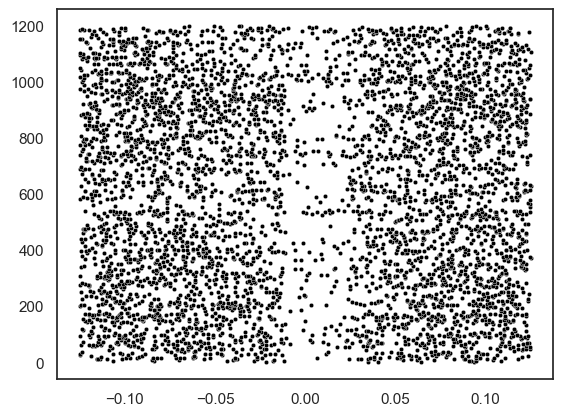

In [6]:
# Plot unit 1

# Python ranges are [a, b), but indexing starts from 0, and goes to length-1,
# so everything works out
spike_times = unit1
plt.show(block=False)


for i in range(0, 1200):
    stim_i = (spike_times >= stim_times[i] - t_before) & (spike_times <= stim_times[i] + t_after)

    spike_i = spike_times[stim_i]
    sns.scatterplot(x=spike_i - stim_times[i], y=np.full(len(spike_i), i), s=10, color='black')


In [ ]:
# Plot unit 2

spike_times = unit2
for i in range(0, len(stim_times)):
    stim_i = (spike_times >= stim_times[i] - t_before) & (spike_times <= stim_times[i] + t_after)
    spike_i = spike_times[stim_i];
    sns.scatterplot(x=spike_i - stim_times[i], y=np.full(len(spike_i), i), s=10, color='black');
